## 1. **Customer Personality Dataset - Data Preprocessing Steps**

https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis/data

This notebook preprocesses the **Customer Personality Dataset** to prepare it for machine learning models. The following steps were performed:

### 1.1 **Load the Dataset**  
   - Read the dataset from `"marketing_campaign.csv"` using `pandas.read_csv()`.
   - Ensured correct delimiter (`\t`).

### 1.2 **Handle Missing Values**  
   - The `Income` column contained missing values, which were filled using the **median value** of the column.

### 1.3 **Feature Engineering**  
   - Converted the `Dt_Customer` column (customer enrollment date) into a new feature: **Customer tenure in days** (`Customer_Days`), calculated as the number of days since the most recent enrollment date.

### 1.4 **Encode Categorical Variables**  
   - Used **One-Hot Encoding** for categorical features:
     - `Education`
     - `Marital_Status`
   - Removed the first category (`drop_first=True`) to avoid multicollinearity.

### 1.5 **Drop Irrelevant Columns**  
   - Removed `ID` (unique identifier) and `Dt_Customer` (original date column) as they are not useful for classification.

### 1.6 **Feature Scaling (Standardization)**  
   - Applied **Z-score standardization** using `StandardScaler()` to scale all numerical features.

### 1.7 **Split Data into Training and Testing Sets**  
   - The dataset was split into:
     - **80% Training set** (`X_train`, `y_train`)
     - **20% Testing set** (`X_test`, `y_test`)
   - Used **stratified sampling** to maintain the class distribution of the target variable (`Response`).

### 1.8 **Save Preprocessed Data**  
   - The processed datasets were saved as:
     - `"customer_train.csv"`
     - `"customer_test.csv"`

### 1.9 **Output Dataset Shapes**  
   - Displayed the number of samples and features in the training and testing sets.

These preprocessing steps ensure that the dataset is **clean, properly formatted, and ready for training classification models**.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset
file_path = "marketing_campaign.csv"  # Ensure the file path is correct
df = pd.read_csv(file_path, sep="\t")  # Read CSV with semicolon delimiter
# df.to_csv("marketing_campaign.csv", index=False)  # Save the CSV file with comma delimiter
# Handle missing values in Income (fill with median value)
df["Income"].fillna(df["Income"].median(), inplace=True)

# Convert Dt_Customer to customer tenure in days
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")
df["Customer_Days"] = (df["Dt_Customer"].max() - df["Dt_Customer"]).dt.days

# Encode categorical variables using One-Hot Encoding
df = pd.get_dummies(df, columns=["Education", "Marital_Status"], drop_first=True)

# Drop irrelevant columns (ID and Dt_Customer)
df.drop(columns=["ID", "Dt_Customer"], inplace=True)

# Define features and target variable
X = df.drop(columns=["Response"])  # Features
y = df[["Response"]]  # Target variable (keep as DataFrame for merging)

# Standardize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and testing sets (80% training, 20% testing, stratified by target variable)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=1024, stratify=y
)

# Convert back to DataFrame for saving
train_set = pd.DataFrame(np.hstack((X_train, y_train)), columns=list(X.columns) + ["Response"])
test_set = pd.DataFrame(np.hstack((X_test, y_test)), columns=list(X.columns) + ["Response"])

# Save train and test sets as CSV files
train_set.to_csv("customer_train.csv", index=False)
test_set.to_csv("customer_test.csv", index=False)

# Print dataset shapes
print("Training set size:", train_set.shape, "Testing set size:", test_set.shape)



## 2 Neural Network Model Training and Evaluation

This section implements a complete workflow for training and evaluating a deep neural network for binary classification. The main steps include:

### 2.1 Data Loading
   - Create a directory (`customer_NN`) for saving results.  
   - Load the training and testing datasets from CSV files and convert them into PyTorch tensors.

### 2.2 **Seed Setting and Class Weight Computation**  
   - Define and call a function (`set_seed`) to set the random seed for reproducibility.
   - Calculate class weights to handle the imbalance in the response variable.

### 2.3 **DNN Model Definition**  
   - Define a `DNN` class with three fully-connected layers, selectable activation functions (ReLU, Tanh, Sigmoid), dropout for regularization, and a final Sigmoid activation for binary classification output.

### 2.4 **Training Function Implementation**  
   - Implement a `train_model` function that trains the DNN using a specified activation function, learning rate, and number of epochs.  
   - The function records the training and testing error at each epoch, saves the log data to a CSV file (if a `save_path` is provided), and returns the error lists.

### 2.5 **Hyperparameter Tuning**  
   - Train models using different activation functions (ReLU, Tanh, Sigmoid) and log their performance.  
   - Determine the best activation function based on the final test error.
   - Experiment with various learning rates (0.0001, 0.001, 0.01, 0.1) using the best activation function and select the optimal learning rate based on test error performance.

### 2.6 **Visualization of Training Curves**  
   - Plot training and testing error curves for each activation function and each learning rate across epochs.  
   - Adjust y-axis limits based on the error values to standardize the visualization across different settings.

### 2.7 **K-Fold Cross-Validation**  
   - Perform 10-fold cross-validation on the final model using the best activation function and learning rate.  
   - Record and save the training and testing errors for each fold and compute average error rates.

### 2.8 **Combined Results and Final Visualization**  
   - Train a final model without cross-validation and compare it with the cross-validation results.  
   - Save a CSV file that combines the non-CV and CV results (including training/test errors and elapsed time).  
   - Generate and save a series of plots that present:
     - Final error by activation function,
     - Final error by learning rate,
     - Error trajectory during training of the final model,
     - K-fold cross-validation error trends,
     - A bar chart comparison of errors for models trained with and without cross-validation.

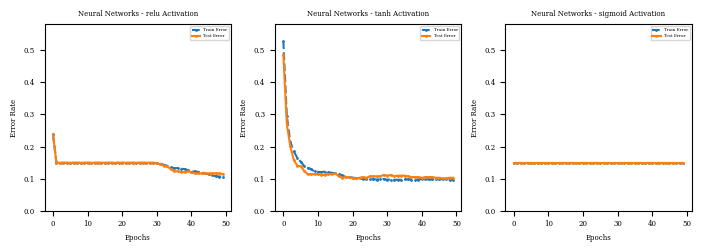

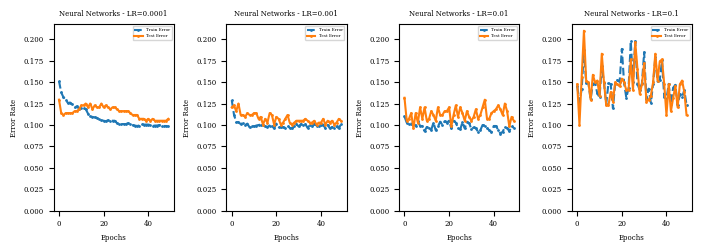

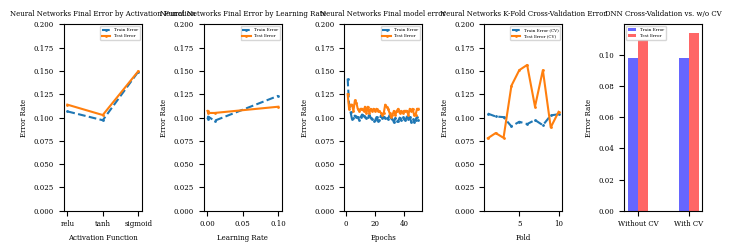

In [47]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import random
import numpy as np
from sklearn.model_selection import KFold
import time


# Create directory for saving results
results_dir = "customer_NN"
os.makedirs(results_dir, exist_ok=True)

# Load training and testing datasets
train_df = pd.read_csv("customer_train.csv")
test_df = pd.read_csv("customer_test.csv")

# Convert to PyTorch tensors
X_train = torch.tensor(train_df.drop(columns=['Response']).values, dtype=torch.float32)
y_train = torch.tensor(train_df['Response'].values, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(test_df.drop(columns=['Response']).values, dtype=torch.float32)
y_test = torch.tensor(test_df['Response'].values, dtype=torch.float32).unsqueeze(1)

# Set random seed for reproducibility
def set_seed(seed=1024):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(1024)

# Compute class weights to handle imbalance
total_samples = len(y_train)
class_counts = torch.tensor([(y_train == 0).sum().item(), y_train.sum().item()])
class_weights = total_samples / (2 * class_counts)

# Define the DNN model
class DNN(nn.Module):
    def __init__(self, input_size, activation='relu'):
        super(DNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.output = nn.Linear(64, 1)
        activations = {'relu': nn.ReLU(), 'tanh': nn.Tanh(), 'sigmoid': nn.Sigmoid()}
        self.activation = activations.get(activation, nn.ReLU())
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.dropout(x)
        x = self.activation(self.fc2(x))
        x = self.dropout(x)
        x = self.activation(self.fc3(x))
        x = self.sigmoid(self.output(x))
        return x

# Training function
def train_model(activation, lr=0.0001, epochs=50, X_train=None, y_train=None, X_test=None, y_test=None, save_path=None):
    if X_train is None or y_train is None or X_test is None or y_test is None:
        X_train, y_train, X_test, y_test = globals()['X_train'], globals()['y_train'], globals()['X_test'], globals()['y_test']
    
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
    model = DNN(input_size=X_train.shape[1], activation=activation)
    # criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights[1])
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    
    train_errors, test_errors = [], []
    log_data = []

    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
        
        model.eval()
        with torch.no_grad():
            train_preds = (model(X_train) >= 0.5).float()
            test_preds = (model(X_test) >= 0.5).float()

            train_error = 1 - (train_preds.eq(y_train).sum() / len(y_train)).item()
            test_error = 1 - (test_preds.eq(y_test).sum() / len(y_test)).item()

        train_errors.append(train_error)
        test_errors.append(test_error)

        # Save log data
        log_data.append([epoch + 1, train_error, test_error])

    # Save logs to CSV
    if save_path:
        df_log = pd.DataFrame(log_data, columns=['Epoch', 'Train Error', 'Test Error'])
        df_log.to_csv(save_path, index=False)

    return train_errors, test_errors

# Train different activation functions
activations = ['relu', 'tanh', 'sigmoid']
activation_train_errors, activation_test_errors = {}, {}

for act in activations:
    log_path = os.path.join(results_dir, f"train_log_activation_{act}.csv")
    train_error, test_error = train_model(activation=act, save_path=log_path)
    activation_train_errors[act] = train_error
    activation_test_errors[act] = test_error
best_activation = activations[np.argmin([activation_test_errors[act][-1] for act in activations])]
# Train different learning rates
learning_rates = [0.0001, 0.001, 0.01, 0.1]
lr_train_errors, lr_test_errors = {}, {}

for lr in learning_rates:
    log_path = os.path.join(results_dir, f"train_log_lr_{lr}.csv")
    train_error, test_error = train_model(activation=best_activation, lr=lr, save_path=log_path)
    lr_train_errors[lr] = train_error
    lr_test_errors[lr] = test_error

best_lr = learning_rates[np.argmin([lr_test_errors[lr][-1] for lr in learning_rates])]
# Function to calculate y-limits per figure group
def get_group_ylim(error_dict):
    all_values = [val for sublist in error_dict.values() for val in sublist]
    ymin, ymax = min(all_values), max(all_values)
    return ymin * 0.85, ymax * 1.1

# Compute y-axis limits separately for each figure group
y_min_a, y_max_a = get_group_ylim(activation_train_errors)
y_min_lr, y_max_lr = get_group_ylim(lr_train_errors)

plt.rcParams.update({
    "font.size": 6,      
    "axes.titlesize": 5,     
    "axes.labelsize":5,     
    "xtick.labelsize": 5,      
    "ytick.labelsize": 5,     
    "legend.fontsize": 3,      
    "lines.markersize": 1,  
    "font.family": "serif", 
})


# Plot activation functions
fig, axes = plt.subplots(1, 3, figsize=(7, 2.5))
for i, act in enumerate(activations):
    axes[i].plot(range(50), activation_train_errors[act], label="Train Error", linestyle='dashed', marker='o')
    axes[i].plot(range(50), activation_test_errors[act], label="Test Error", marker='o')
    axes[i].set_title(f"Neural Networks - {act} Activation")
    axes[i].set_xlabel("Epochs")
    axes[i].set_ylabel("Error Rate")
    axes[i].set_ylim(0,y_max_a)
    axes[i].legend()
fig.tight_layout()
plt.savefig(os.path.join(results_dir, "customer_nn_activation_error_rate.png"), dpi=300)
plt.show()

# Plot learning rates
fig, axes = plt.subplots(1, 4, figsize=(7, 2.5))
for i, lr in enumerate(learning_rates):
    axes[i].plot(range(50), lr_train_errors[lr], label="Train Error", linestyle='dashed', marker='o')
    axes[i].plot(range(50), lr_test_errors[lr], label="Test Error", marker='o')
    axes[i].set_title(f"Neural Networks - LR={lr}")
    axes[i].set_xlabel("Epochs")
    axes[i].set_ylabel("Error Rate")
    axes[i].set_ylim(0,y_max_lr)
    axes[i].legend()
fig.tight_layout()
plt.savefig(os.path.join(results_dir, "customer_nn_lr_error_rate.png"), dpi=300)
plt.show()


# K-Fold CV
k_folds = 10
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)


def cross_validate_final_model(activation, lr, epochs=50):
    fold_train_errors = []
    fold_test_errors = []
    log_data = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):
        X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

        train_error, test_error = train_model(activation=activation, lr=lr, epochs=epochs,
                                              X_train=X_train_fold, y_train=y_train_fold,
                                              X_test=X_val_fold, y_test=y_val_fold)

        fold_train_errors.append(train_error[-1])
        fold_test_errors.append(test_error[-1])

        # Save fold errors
        log_data.append([fold_idx, train_error, test_error])

    # Save cross-validation logs
    log_path = os.path.join(results_dir, f"cross_validation_log_{activation}_{lr}.csv")
    df_log = pd.DataFrame(log_data, columns=['Fold', 'Train Error', 'Test Error'])
    df_log.to_csv(log_path, index=False)

    cv_train_error = np.mean(fold_train_errors)
    cv_test_error = np.mean(fold_test_errors)

    # print("Fold-wise Train Errors:", fold_train_errors)
    # print("Fold-wise Test Errors:", fold_test_errors)
    # print(f"Final CV Train Error: {cv_train_error}")
    # print(f"Final CV Test Error: {cv_test_error}")

    return cv_train_error, cv_test_error, fold_train_errors, fold_test_errors

# Get the Best Activation Function & Learning Rate**
# best_activation = best_activation
# best_lr = b

# Train without Cross-Validation to get best non-CV error**
non_cv_log_path = os.path.join(results_dir, "train_log_non_cv.csv")
start_non_cv = time.time()
best_non_cv_train_error, best_non_cv_test_error = train_model(best_activation, best_lr, save_path=non_cv_log_path)
end_non_cv = time.time()
non_cv_duration = end_non_cv - start_non_cv

# Run Cross-Validation to get CV errors**
start_cv = time.time()
cv_train_error, cv_test_error, cv_train_errors, cv_test_errors = cross_validate_final_model(best_activation, best_lr)
end_cv = time.time()
cv_duration = end_cv - start_cv

# **Save combined results (non-CV and CV) to a single CSV**
final_results = [
    {
        "Model": "Non-CV",
        "Time(s)": non_cv_duration,
        "Train_Error": best_non_cv_train_error[-1] if isinstance(best_non_cv_train_error, list) else best_non_cv_train_error,
        "Test_Error": best_non_cv_test_error[-1] if isinstance(best_non_cv_test_error, list) else best_non_cv_test_error
    },
    {
        "Model": "CV",
        "Time(s)": cv_duration,
        "Train_Error": cv_train_error,
        "Test_Error": cv_test_error
    }
]

pd.DataFrame(final_results).to_csv(os.path.join(results_dir, "dnn_log.csv"), index=False)

# Final Figure Set 3
fig, axes = plt.subplots(1, 5, figsize=(7, 2.5))

# Ensure all subplots share the same y-axis scale
min_error = min(0, min(cv_train_errors), min(cv_test_errors), best_non_cv_train_error[-1], cv_train_error)
max_error = max(0.2, max(cv_train_errors), max(cv_test_errors), best_non_cv_test_error[-1], cv_test_error)

# Subplot 1: Final Error by Activation Function
final_activation_train_errors = [activation_train_errors[act][-1] for act in activations] 
final_activation_test_errors = [activation_test_errors[act][-1] for act in activations]

axes[0].plot(activations, final_activation_train_errors, marker='o', linestyle='dashed', label="Train Error")
axes[0].plot(activations, final_activation_test_errors, marker='o', label="Test Error")
axes[0].set_title("Neural Networks Final Error by Activation Function")
axes[0].set_ylabel("Error Rate")
axes[0].set_xlabel("Activation Function")
axes[0].legend()
axes[0].set_ylim(min_error, max_error)

# **Subplot 2: Final Error by Learning Rate**
final_lr_train_errors = [lr_train_errors[lr][-1] for lr in learning_rates]
final_lr_test_errors = [lr_test_errors[lr][-1] for lr in learning_rates]
axes[1].plot(learning_rates, final_lr_train_errors, marker='o', linestyle='dashed', label="Train Error")
axes[1].plot(learning_rates, final_lr_test_errors, marker='o', label="Test Error")
axes[1].set_title("Neural Networks Final Error by Learning Rate")
axes[1].set_xlabel("Learning Rate")
axes[1].set_ylabel("Error Rate")
axes[1].legend()
axes[1].set_ylim(min_error, max_error)

# **Subplot 3: Final model errors**
axes[2].plot(range(1,51), best_non_cv_train_error, marker='o', linestyle='dashed', label="Train Error")
axes[2].plot(range(1,51), best_non_cv_test_error, marker='o', label="Test Error")
axes[2].set_title("Neural Networks Final model error")
axes[2].set_xlabel("Epochs")
axes[2].set_ylabel("Error Rate")
axes[2].legend()
axes[2].set_ylim(min_error, max_error)

# **Subplot 3: K-Fold Cross-Validation Error**
axes[3].plot(range(1, k_folds+1), cv_train_errors, marker='o', linestyle='dashed', label="Train Error (CV)")
axes[3].plot(range(1, k_folds+1), cv_test_errors, marker='o', label="Test Error (CV)")
axes[3].set_title("Neural Networks K-Fold Cross-Validation Error")
axes[3].set_xlabel("Fold")
axes[3].set_ylabel("Error Rate")
axes[3].legend()
axes[3].set_ylim(min_error, max_error)

# **Subplot 4: CV vs. No-CV Bar Chart**
# print("Non-CV Train Error:", best_non_cv_train_error[-1])
# print("Non-CV Test Error:", best_non_cv_test_error[-1])
# print("CV Train Errors median:", np.median(cv_train_errors))
# print("CV Test Errors median:", np.median(cv_test_errors))
# print("CV Train Error:", cv_train_error)
# print("CV Test Error:", cv_test_error)


labels = ["Without CV", "With CV"]
x = np.arange(len(labels))
width = 0.2
axes[4].bar(x - width/2, [best_non_cv_train_error[-1], cv_train_error], width, label="Train Error", color='b', alpha=0.6)
axes[4].bar(x + width/2, [best_non_cv_test_error[-1], cv_test_error], width, label="Test Error", color='r', alpha=0.6)
axes[4].set_title("DNN Cross-Validation vs. w/o CV")
axes[4].set_xticks(x)
axes[4].set_xticklabels(labels)
axes[4].set_ylabel("Error Rate")
axes[4].legend()
# axes[3].set_ylim(min_error, max_error)
fig.tight_layout()
plt.savefig(os.path.join(results_dir, "customer_nn_final_comparison_with_cv.png"), dpi=300)
plt.show()


## 3. K-Nearest Neighbors (KNN) Model Training, Tuning, and Evaluation

### 3.1 Data Loading
- Create a results directory named `customer_KNN`.
- Load the training and testing datasets from CSV files.
- Extract features (X) and the target variable (y) from the datasets.

### 3.2 Hyperparameter Tuning
- Define a range of K values and select distance metrics (`euclidean`, `manhattan`, `minkowski`).
- For each combination of K and distance metric, train a KNN classifier.
- Compute training and testing error rates for each configuration.
- Record the errors and hyperparameter tuning execution times, and save these results to a CSV file.

### 3.3 Best Model Selection
- Identify the optimal K and distance metric based on the lowest test error observed during hyperparameter tuning.

### 3.4 Final Model Training and Evaluation (Non-Cross-Validation)
- Train the KNN model on the full training dataset using the best hyperparameters.
- Evaluate the model’s performance on both the training and testing datasets.
- Measure and record the wall clock time required for non-cross-validated model training and evaluation.

### 3.5 10-Fold Cross-Validation
- Perform 10-fold cross-validation using the best KNN configuration.
- For each fold, compute the training and testing error rates.
- Calculate the mean training and testing errors across the folds and record the execution time.

### 3.6 Results Visualization and Saving
- Save the full results (including error rates and execution times for both non-CV and CV scenarios) into a CSV file.
- Generate plots to illustrate:
  - Hyperparameter tuning results (errors versus K for each distance metric).
  - K-Fold cross-validation error trends.
  - A comparison bar chart between non-cross-validated and cross-validated model performance.

best k: 5


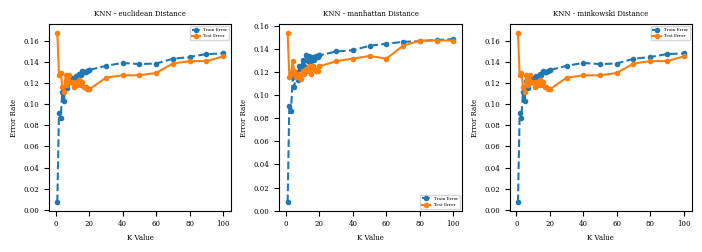

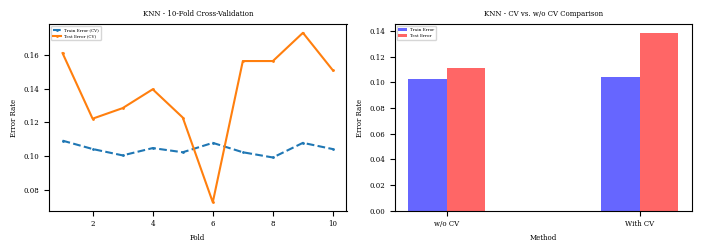

In [48]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

# Create directory for saving results
results_dir = "customer_KNN"
os.makedirs(results_dir, exist_ok=True)

# Load training and testing datasets
train_df = pd.read_csv("customer_train.csv")
test_df = pd.read_csv("customer_test.csv")

# Extract features and target variable
X_train = train_df.drop(columns=['Response']).values
y_train = train_df['Response'].values
X_test = test_df.drop(columns=['Response']).values
y_test = test_df['Response'].values

# Define hyperparameters: K values and distance metrics
k_values = list(range(1, 21)) + list(range(20, 101, 10))
distance_metrics = ["euclidean", "manhattan", "minkowski"]

# Store KNN results and wall clock times
knn_results = {}
timing_results = []
training_errors_records = []  # Store training errors for all K values

# Measure execution time for hyperparameter tuning
for metric in distance_metrics:
    train_errors, test_errors = [], []
    start_time = time.time()  # Start timer
    
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train, y_train)
        
        # Predictions
        train_pred = knn.predict(X_train)
        test_pred = knn.predict(X_test)
        
        # Compute error rates
        train_error = 1 - accuracy_score(y_train, train_pred)
        test_error = 1 - accuracy_score(y_test, test_pred)
        
        train_errors.append(train_error)
        test_errors.append(test_error)
        
        # Store errors for CSV
        training_errors_records.append({"K": k, "Metric": metric, "Train Error": train_error, "Test Error": test_error})

    elapsed_time = time.time() - start_time  # End timer
    knn_results[metric] = {'train_errors': train_errors, 'test_errors': test_errors}
    timing_results.append({"Metric": metric, "Phase": "Hyperparameter Tuning", "Time (s)": elapsed_time})

# Save training errors for different K values
pd.DataFrame(training_errors_records).to_csv(os.path.join(results_dir, "knn_training_errors.csv"), index=False)

# Find the best K and metric (based on lowest test error)**
best_metric, best_k = None, None
best_test_error, best_train_error = float('inf'), float('inf')

for metric in distance_metrics:
    min_error_idx = np.argmin(knn_results[metric]['test_errors'])
    if knn_results[metric]['test_errors'][min_error_idx] < best_test_error:
        best_test_error = knn_results[metric]['test_errors'][min_error_idx]
        best_train_error = knn_results[metric]['train_errors'][min_error_idx]
        best_metric = metric
        best_k = k_values[min_error_idx]

best_metric = 'euclidean'
print('best k:', best_k)

# **Train the Best KNN Model Separately (Non-CV, 50 epochs)**
start_time_non_cv = time.time()
best_knn = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
best_knn.fit(X_train, y_train)
train_pred_non_cv = best_knn.predict(X_train)
test_pred_non_cv = best_knn.predict(X_test)
best_train_error_non_cv = 1 - accuracy_score(y_train, train_pred_non_cv)
best_test_error_non_cv = 1 - accuracy_score(y_test, test_pred_non_cv)
elapsed_time_non_cv = time.time() - start_time_non_cv

# Perform 10-Fold Cross-Validation using the best K and metric**
kf = KFold(n_splits=10, shuffle=True, random_state=1024)
cv_train_errors, cv_test_errors = [], []

start_time_cv = time.time()  # Start timer for CV

for train_idx, val_idx in kf.split(X_train):
    X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

    knn = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
    knn.fit(X_train_fold, y_train_fold)

    train_pred = knn.predict(X_train_fold)
    test_pred = knn.predict(X_val_fold)

    cv_train_errors.append(1 - accuracy_score(y_train_fold, train_pred))
    cv_test_errors.append(1 - accuracy_score(y_val_fold, test_pred))

elapsed_time_cv = time.time() - start_time_cv  # End timer for CV
cv_train_error_mean = np.mean(cv_train_errors)
cv_test_error_mean = np.mean(cv_test_errors)

# Save full results (non-CV and CV) to a single CSV**
full_results = [
    {
        "Metric": best_metric,
        "Best K": best_k,
        "Phase": "Non-CV Training",
        "Train_Error": best_train_error_non_cv,
        "Test_Error": best_test_error_non_cv,
        "Time(s)": elapsed_time_non_cv
    },
    {
        "Metric": best_metric,
        "Best K": best_k,
        "Phase": "Cross-Validation",
        "Train_Error": cv_train_error_mean,
        "Test_Error": cv_test_error_mean,
        "Time(s)": elapsed_time_cv
    }
]

pd.DataFrame(full_results).to_csv(os.path.join(results_dir, "knn_log.csv"), index=False)

plt.rcParams.update({
    "font.size": 6,      
    "axes.titlesize": 5,     
    "axes.labelsize":5,     
    "xtick.labelsize": 5,      
    "ytick.labelsize": 5,     
    "legend.fontsize": 3,      
    "lines.markersize": 1,  
    "font.family": "serif", 
})

# **Plot KNN hyperparameter tuning results (Unified Y-axis)**
fig, axes = plt.subplots(1, 3, figsize=(7, 2.5))
for i, metric in enumerate(distance_metrics):
    axes[i].plot(k_values, knn_results[metric]['train_errors'], label="Train Error", linestyle='dashed', marker='o', markersize=3)
    axes[i].plot(k_values, knn_results[metric]['test_errors'], label="Test Error", marker='o', markersize=3)
    axes[i].set_title(f"KNN - {metric} Distance")
    axes[i].set_xlabel("K Value")
    axes[i].set_ylabel("Error Rate")
    axes[i].legend()
fig.tight_layout()
plt.savefig(os.path.join(results_dir, "knn_k_vs_error.png"), dpi=300)
plt.show()

# **Plot K-Fold CV results & Final Comparison**
fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))

# Left Plot: K-Fold CV errors
axes[0].plot(range(1, 11), cv_train_errors, label="Train Error (CV)", linestyle='dashed', marker='o')
axes[0].plot(range(1, 11), cv_test_errors, label="Test Error (CV)", marker='o')
axes[0].set_title("KNN - 10-Fold Cross-Validation")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Error Rate")
axes[0].legend()

# **Right Plot: No-CV vs. CV Bar Chart**
x_labels = ["w/o CV", "With CV"]
x = np.arange(len(x_labels))
width = 0.2
axes[1].bar(x - width/2, [best_train_error_non_cv, cv_train_error_mean], width, label="Train Error", color='b', alpha=0.6)
axes[1].bar(x + width/2, [best_test_error_non_cv, cv_test_error_mean], width, label="Test Error", color='r', alpha=0.6)
axes[1].set_title("KNN - CV vs. w/o CV Comparison")
axes[1].set_xlabel("Method")
axes[1].set_ylabel("Error Rate")
axes[1].set_xticks(x)
axes[1].set_xticklabels(x_labels)
axes[1].legend()
fig.tight_layout()
plt.savefig(os.path.join(results_dir, "knn_final_comparison.png"), dpi=300)
plt.show()


## 4 SVM Model Training and Evaluation Structure

This code follows a typical structure for model training and evaluation:

### 4.1 **Setup & Data Loading**
   - Set random seed for reproducibility.
   - Create a directory to save results.
   - Load and preprocess training/testing data from CSV files.

### 4.2 **Model Configuration & Training**
   - Define different configurations for the SVM model (various kernels and C values).
   - use class_weight='balanced' in the model
   - Train the SVM for each configuration and compute error rates on train/test sets.

### 4.3 **Performance Analysis**
   - Plot learning curves for different kernels.
   - Evaluate the effect of different C values on model performance.
   - Use 10-fold cross-validation to assess model stability and compare with non-CV training.

### 4.4 **Results & Saving**
   - Save plots visualizing error rates and comparisons.
   - Log training times and error rates into a CSV file.

Best Kernel: rbf


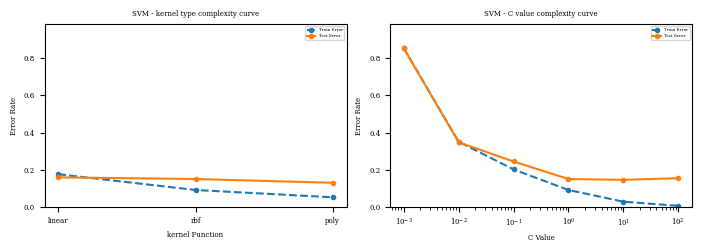

Best C: 1


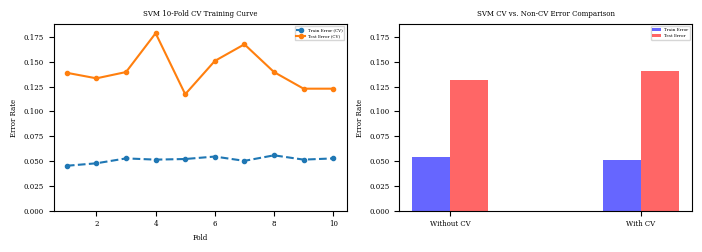

In [49]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import random
from sklearn.svm import SVC
from sklearn.model_selection import learning_curve, cross_val_score, KFold

# Set random seed to match DNN configuration
def set_seed(seed=1024):
    random.seed(seed)
    np.random.seed(seed)

set_seed(1024)

# Create directory for saving results
results_dir = "customer_SVM"
os.makedirs(results_dir, exist_ok=True)

# Load training and testing datasets
train_df = pd.read_csv("customer_train.csv")
test_df = pd.read_csv("customer_test.csv")

# Extract features and labels
X_train = train_df.drop(columns=['Response']).values
y_train = train_df['Response'].values
X_test = test_df.drop(columns=['Response']).values
y_test = test_df['Response'].values

# Define SVM kernels & C values
kernels = ["linear", "rbf", "poly"]
C_values = [0.001,0.01, 0.1, 1, 10,100]
train_sizes = np.linspace(0.1, 1.0, 10)

# Store all training & test errors
kernel_logs = {}
C_logs = {}

# 1️ First Set of Plots: Learning Curves for Different Kernels (Ensure same y-scale)
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))

kernel_train_error, kernel_test_error = [], []

plt.rcParams.update({
    "font.size": 6,      
    "axes.titlesize": 5,     
    "axes.labelsize":5,     
    "xtick.labelsize": 5,      
    "ytick.labelsize": 5,     
    "legend.fontsize": 3,      
    "lines.markersize": 1,  
    "font.family": "serif", 
})

for i, kernel in enumerate(kernels):
    model = SVC(kernel=kernel, C=1.0, random_state=1024, class_weight='balanced')
    model.fit(X_train, y_train)

    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)

    train_error = 1 - train_accuracy 
    test_error = 1 - test_accuracy 

    kernel_train_error.append(train_error)  
    kernel_test_error.append(test_error)  

kernal_logs = {'kernel': kernels, 'train_error': kernel_train_error, 'test_error': kernel_test_error}
pd.DataFrame(kernal_logs).to_csv(os.path.join(results_dir, "customer_SVM_kernel_logs.csv"), index=False)

k_y_min, k_y_max = min(0, min(kernel_test_error), min(kernel_train_error)), max( max(kernel_test_error), max(kernel_train_error))
axes[0].plot(kernels, kernel_train_error, label="Train Error", linestyle="dashed", marker="o", markersize=3)
axes[0].plot(kernels, kernel_test_error, label="Test Error", marker="o", markersize=3)
axes[0].set_title(f"SVM - kernel type complexity curve")
axes[0].set_xlabel("kernel Function")
axes[0].set_ylabel("Error Rate")
axes[0].legend()

# best_kernel = kernels[np.argmin(kernel_test_error)]
best_kernel = 'rbf'
print(f"Best Kernel: {best_kernel}")
# 2️ Second Set of Plots: Training Size vs. Error for Different C Values (Ensure same y-scale)
# -----------------------------------------------------------------------------
c_train_error, c_test_error = [], []
for i, c in enumerate(C_values):
    model = SVC(kernel=best_kernel, C=c, random_state=1024, class_weight='balanced')
    model.fit(X_train, y_train)

    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)

    train_error = 1 - train_accuracy 
    test_error = 1 - test_accuracy 

    c_train_error.append(train_error)  
    c_test_error.append(test_error)  

C_logs = {'C': C_values, 'train_error': c_train_error, 'test_error': c_test_error}
pd.DataFrame(C_logs).to_csv(os.path.join(results_dir, "customer_SVM_C_logs.csv"), index=False)

C_str = [str(c) for c in C_values]
c_y_min, c_y_max = min(0, min(c_test_error), min(c_train_error)), max( max(c_test_error), max(c_train_error))
axes[1].plot(C_values, c_train_error, label="Train Error", linestyle="dashed", marker="o", markersize=3)
axes[1].plot(C_values, c_test_error, label="Test Error", marker="o", markersize=3)
plt.xscale("log")
axes[1].set_title(f"SVM - C value complexity curve")
axes[1].set_xlabel("C Value")
axes[1].set_ylabel("Error Rate")
axes[1].legend()

y_min, y_max = min(k_y_min, k_y_min), max(c_y_max, c_y_max)
for ax in axes:
    ax.set_ylim(y_min * 0.85, y_max * 1.15)
fig.tight_layout()
plt.savefig(os.path.join(results_dir, "complexity curcve.png"), dpi=300)
plt.show()

# best_c = C_values[np.argmin(c_test_error)]
best_c = 1
print(f"Best C: {best_c}")
# 3 Third Set of Plots: Cross-Validation & Complexity Analysis (Ensure same y-scale)
# -----------------------------------------------------------------------------
C_best = best_c
kernel_best = 'poly'  # Assume the best kernel

# non-cv
start_time_non_cv = time.time()
svm_no_cv = SVC(kernel=kernel_best, C=C_best, random_state=1024,class_weight='balanced')
svm_no_cv.fit(X_train, y_train)
end_time_non_cv = time.time()
non_cv_time = end_time_non_cv - start_time_non_cv
non_cv_train_error = 1 - svm_no_cv.score(X_train, y_train)
non_cv_test_error = 1 - svm_no_cv.score(X_test, y_test)

#cv
kf = KFold(n_splits=10, shuffle=True, random_state=1024)
start_time_cv = time.time()

cv_model = SVC(kernel=kernel_best, C=C_best, random_state=1024,class_weight='balanced')
cv_test_scores = cross_val_score(cv_model, X_train, y_train, cv=kf, scoring="accuracy")
cv_test_error = 1 - np.mean(cv_test_scores)

cv_train_errors = []
for train_idx, val_idx in kf.split(X_train):
    X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
    
    cv_model.fit(X_train_fold, y_train_fold)
    train_accuracy = cv_model.score(X_train_fold, y_train_fold)
    cv_train_errors.append(1 - train_accuracy)

cv_train_error = np.mean(cv_train_errors)

end_time_cv = time.time()
cv_time = end_time_cv - start_time_cv

fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))

# 1️ 10-Fold CV
axes[0].plot(range(1, 11), cv_train_errors, linestyle="dashed", marker="o", markersize = 3,label="Train Error (CV)")
axes[0].plot(range(1, 11), 1 - cv_test_scores, marker="o",markersize = 3, linestyle="-", label="Test Error (CV)")
axes[0].set_title("SVM 10-Fold CV Training Curve")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Error Rate")
axes[0].legend()

# 2️ Non-CV vs. CV
labels = ["Without CV", "With CV"]
x = np.arange(len(labels))
width = 0.2
axes[1].bar(x - width/2, [non_cv_train_error, cv_train_error], width, label="Train Error", color='b', alpha=0.6)
axes[1].bar(x + width/2, [non_cv_test_error, cv_test_error], width, label="Test Error", color='r', alpha=0.6)
axes[1].set_title("SVM CV vs. Non-CV Error Comparison")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("Error Rate")
axes[1].legend()

y_min_2, y_max_2 = min(0, min(cv_train_errors), min(1 - cv_test_scores)), max(max(cv_train_errors), max(1 - cv_test_scores))

for ax in axes:
    ax.set_ylim(y_min_2 * 0.85, y_max_2 * 1.05)
fig.tight_layout()
plt.savefig(os.path.join(results_dir, "customer_final_analysis.png"), dpi=300)
plt.show()

# save
time_log_df = pd.DataFrame({
    "Model": ["Non-CV", "CV"],
    "Time(s)": [non_cv_time, cv_time],
    "Train_Error": [non_cv_train_error, cv_train_error],
    "Test_Error": [non_cv_test_error, cv_test_error]
})
time_log_df.to_csv(os.path.join(results_dir, "SVM_log.csv"), index=False)


## 5. Model Comparison Analysis
This section presents a comparative analysis of Deep Neural Networks (DNNs), Support Vector Machines (SVMs), and K-Nearest Neighbors (KNNs) in terms of training time and model performance.

### 5.1 Setup and Data Loading
A results directory Model_Comparison is created to store outputs.
Training logs for DNN, SVM, and KNN are loaded from CSV files.
KNN logs are split into Non-CV Training and Cross-Validation phases for separate analysis.
### 5.2 Key Metrics Extraction
Wall Clock Training Time: Extracted for both non-cross-validation (Non-CV) and cross-validation (CV) phases.
Model Performance (Error Rates):
Training Error (Non-CV vs. CV)
Test Error (Non-CV vs. CV)
Why Compare These?
Evaluating the trade-off between computational cost and generalization.
Checking how cross-validation affects error rates.
### 5.3 Visualization
(1) Wall Clock Time Comparison
Compares training times across models (DNN, SVM, KNN) for both Non-CV and CV.
Uses a logarithmic scale to accommodate differences in scale.
Expected trends:
CV takes significantly longer than Non-CV due to repeated training.
DNN is typically more computationally expensive than SVM and KNN.
(2) Train & Test Error Comparison
Compares train & test errors across models.
Each model has four bars:
Non-CV Train Error
CV Train Error
Non-CV Test Error
CV Test Error
### 5.4 Saving and Displaying Results
The final figure is saved as final_model_comparison.png.

<>:12: SyntaxWarning: invalid escape sequence '\G'
<>:13: SyntaxWarning: invalid escape sequence '\G'
<>:12: SyntaxWarning: invalid escape sequence '\G'
<>:13: SyntaxWarning: invalid escape sequence '\G'
C:\Users\louis\AppData\Local\Temp\ipykernel_41848\1251340552.py:12: SyntaxWarning: invalid escape sequence '\G'
  svm_log = pd.read_csv("D:\Gatech\CS7641 Machine Learning\A1\customer_SVM\SVM_log.csv")
C:\Users\louis\AppData\Local\Temp\ipykernel_41848\1251340552.py:13: SyntaxWarning: invalid escape sequence '\G'
  knn_log = pd.read_csv("D:\Gatech\CS7641 Machine Learning\A1\customer_KNN\knn_log.csv")


non_cv_train_time: [np.float64(2.965481758117676), np.float64(0.0909397602081298), np.float64(0.0464322566986084)]
cv_train_time: [np.float64(26.63942861557007), np.float64(0.6923794746398926), np.float64(1.060319900512695)]


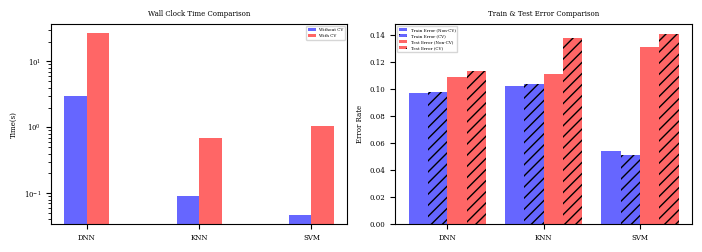

In [51]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set the results directory
results_dir = "customer_Model_Comparison"
os.makedirs(results_dir, exist_ok=True)

# Load the training logs
dnn_log = pd.read_csv(r"D:\Gatech\CS7641 Machine Learning\A1\customer_NN\dnn_log.csv")
svm_log = pd.read_csv("D:\Gatech\CS7641 Machine Learning\A1\customer_SVM\SVM_log.csv")
knn_log = pd.read_csv("D:\Gatech\CS7641 Machine Learning\A1\customer_KNN\knn_log.csv")

# Extract Non-CV & CV data
models = ["DNN", "KNN", "SVM"]

# Extract KNN logs (handling different format)
knn_non_cv = knn_log[knn_log["Phase"] == "Non-CV Training"]
knn_cv = knn_log[knn_log["Phase"] == "Cross-Validation"]

# Extract training times
non_cv_train_time = [
    dnn_log.loc[dnn_log["Model"] == "Non-CV", "Time(s)"].values[0],
    knn_non_cv["Time(s)"].values[0],
    svm_log.loc[svm_log["Model"] == "Non-CV", "Time(s)"].values[0],
]

cv_train_time = [
    dnn_log.loc[dnn_log["Model"] == "CV", "Time(s)"].values[0],
    knn_cv["Time(s)"].values[0],
    svm_log.loc[svm_log["Model"] == "CV", "Time(s)"].values[0],
]

# Extract train/test error rates
non_cv_train_error = [
    dnn_log.loc[dnn_log["Model"] == "Non-CV", "Train_Error"].values[0],
    knn_non_cv["Train_Error"].values[0],
    svm_log.loc[svm_log["Model"] == "Non-CV", "Train_Error"].values[0],
]

cv_train_error = [
    dnn_log.loc[dnn_log["Model"] == "CV", "Train_Error"].values[0],
    knn_cv["Train_Error"].values[0],
    svm_log.loc[svm_log["Model"] == "CV", "Train_Error"].values[0],
]

non_cv_test_error = [
    dnn_log.loc[dnn_log["Model"] == "Non-CV", "Test_Error"].values[0],
    knn_non_cv["Test_Error"].values[0],
    svm_log.loc[svm_log["Model"] == "Non-CV", "Test_Error"].values[0],
]

cv_test_error = [
    dnn_log.loc[dnn_log["Model"] == "CV", "Test_Error"].values[0],
    knn_cv["Test_Error"].values[0],
    svm_log.loc[svm_log["Model"] == "CV", "Test_Error"].values[0],
]

final_logs = {'models': models, 'non_cv_train_time': non_cv_train_time, 'cv_train_time': cv_train_time, 'non_cv_train_error': non_cv_train_error, 'cv_train_error': cv_train_error, 'non_cv_test_error': non_cv_test_error, 'cv_test_error': cv_test_error}
pd.DataFrame(final_logs).to_csv(os.path.join(results_dir, "customer_final_model_comparison.csv"), index=False)

plt.rcParams.update({
    "font.size": 6,      
    "axes.titlesize": 5,     
    "axes.labelsize":5,     
    "xtick.labelsize": 5,      
    "ytick.labelsize": 5,     
    "legend.fontsize": 3,      
    "lines.markersize": 1,  
    "font.family": "serif", 
})

fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))
# 1️. Training Time Comparison (per model: Non-CV & CV)
x = np.arange(len(models))
width = 0.2

axes[0].bar(x - width/2, non_cv_train_time, width, color='blue', alpha=0.6, label="Without CV")
axes[0].bar(x + width/2, cv_train_time, width, color='red', alpha=0.6, label="With CV")
axes[0].set_yscale('log')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_title("Wall Clock Time Comparison")
axes[0].set_ylabel("Time(s)")
axes[0].legend()
print('non_cv_train_time:', non_cv_train_time)
print('cv_train_time:', cv_train_time)

# 2️. Train & Test Error Comparison
x = np.arange(len(models))
# width = 0.2

axes[1].bar(x - width, non_cv_train_error, width, label="Train Error (Non-CV)", color="blue", alpha=0.6)
axes[1].bar(x, cv_train_error, width, label="Train Error (CV)", color="blue", hatch="///", alpha=0.6)
axes[1].bar(x + width, non_cv_test_error, width, label="Test Error (Non-CV)", color="red", alpha=0.6)
axes[1].bar(x + 2*width, cv_test_error, width, label="Test Error (CV)", color="red", hatch="///", alpha=0.6)

axes[1].set_xticks(x + width/2)
axes[1].set_xticklabels(models)
axes[1].set_title("Train & Test Error Comparison")
axes[1].set_ylabel("Error Rate")
axes[1].legend()

# Save and show plots
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "customer_final_model_comparison.png"), dpi=300)
plt.show()
